<a href="https://colab.research.google.com/github/Zinniacodes01/Zinnia-s-Code/blob/main/Tensorflowregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#download ipynb

In [ ]:
url ='http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
columns = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight','Acceleration', 'Model Year', 'Origin']
df = pd.read_csv(url, names=columns, sep=' ', skipinitialspace=True, comment='\t', na_values='?')
print(df.head())

    MPG  Cylinders  Displacement  Horsepower  Weight  Acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   Model Year  Origin  
0          70       1  
1          70       1  
2          70       1  
3          70       1  
4          70       1  


In [ ]:
print(df.isnull().sum())
df.dropna(inplace=True,axis=0)
print(df.isnull().sum())

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64
MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64


In [ ]:
train_dataset = df.sample(frac=0.8, random_state=42)
test_dataset = df.drop(train_dataset.index)
print(train_dataset.shape)
print(test_dataset.shape)

(314, 8)
(78, 8)


In [ ]:
xtrain=train_dataset.drop('MPG',axis=1)
ytrain=train_dataset['MPG']
xtest=test_dataset.drop('MPG',axis=1)
ytest=test_dataset['MPG']
print(xtrain.shape)
print(ytrain.shape)
print(xtest.shape)
print(ytest.shape)

(314, 7)
(314,)
(78, 7)
(78,)


In [ ]:
train_dataset.describe()#normalization:all cols go with the same scale /255

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
count,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000
mean,23.153822,5.531847,197.855096,105.971338,3005.745223,15.510828,75.910828,1.579618
std,7.861854,1.729449,106.501896,39.636557,859.060925,2.803560,3.688989,0.808322
min,9.000000,3.000000,68.000000,46.000000,1649.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,76.000000,2231.000000,13.625000,73.000000,1.000000
50%,22.000000,4.000000,151.000000,95.000000,2831.500000,15.500000,76.000000,1.000000
75%,28.075000,8.000000,302.000000,130.000000,3641.750000,17.000000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,4955.000000,24.800000,82.000000,3.000000


In [ ]:
normalizer=tf.keras.layers.Normalization(axis=-1)
xtrain = np.array(xtrain)
normalizer.adapt(xtrain)
#normalization is IMPORTANT

In [ ]:
# model = tf.keras.Sequential([
# normalizer,
#     tf.keras.layers.Dense(1)
# ])<-simple neural network
model=tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64,activation='relu'),# relu is IMPORTANT(Rectified Linear Unit,f(x)= if x>0: f(x)=x if x<=0: f(x)=0)
    tf.keras.layers.Dense(64,activation='relu'),#experiment: does adding layers or making numers bigger(binary only) do better
    tf.keras.layers.Dense(64,activation='relu'),#more layers  or more nodes does not mean more accuracy!
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(1)
])#<-dense neural network

In [ ]:
model.compile(loss='mean_absolute_error',optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

In [ ]:
history=model.fit(xtrain,ytrain,epochs=100,validation_split=0.2)# validation is IMPORTANT
#20%TESTING, 80% TRAINING
#               ^
# 20% VALIDATION  80%TRAINING

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - loss: 23.3447 - val_loss: 21.1760
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.2923 - val_loss: 19.5629
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 20.6742 - val_loss: 16.1650
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16.5317 - val_loss: 12.2802
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11.7899 - val_loss: 8.0418
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.2895 - val_loss: 5.5782
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.1121 - val_loss: 4.8243
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.8752 - val_loss: 3.4653
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.4171 - val_loss: 3.0182
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.8724 - val_loss: 2.6887
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.5923 - val_loss: 2.4509
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.6761 - val_lo

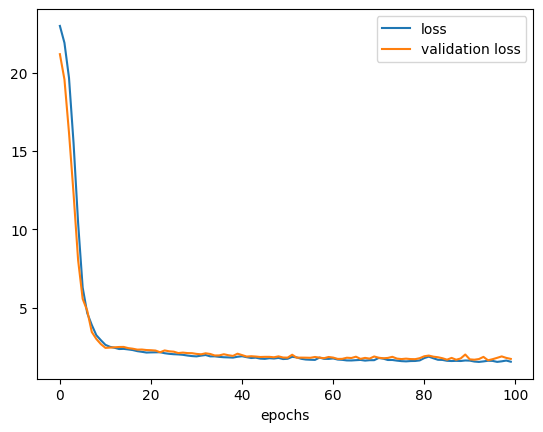

In [ ]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel('epochs')
plt.legend()
plt.show()

In [ ]:
test_loss=model.evaluate(xtest,ytest)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 1.6592


In [ ]:
y_predict=model.predict(np.array([[8,307,130,3504,12,70,1]]))
print(y_predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
[[18.11267]]


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url='https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv'
columns=['Sex',
'Length',
'Diameter',
'Height',
'Whole weight',
'Shucked weight',
'Viscera weight',
'Shell weight',
'Age of abalone']
df = pd.read_csv(url, names=columns, sep=' ', skipinitialspace=True, comment='\t', na_values='?')
df.dropna(inplace=True,axis=0)
train_dataset = df.sample(frac=0.8, random_state=42)
test_dataset = df.drop(train_dataset.index)
xtrain=train_dataset.drop('Age of abalone',axis=1)
ytrain=train_dataset['Age of abalone']
xtest=test_dataset.drop('Age of abalone',axis=1)
ytest=test_dataset['Age of abalone']
train_dataset.describe()
normalizer=tf.keras.layers.Normalization(axis=-1)
xtrain=np.array(xtrain)
normalizer.adapt(xtrain+1)
model=tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(1)
])#<-dense neural network
model.compile(loss='mean_absolute_error',optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
history=model.fit(xtrain,ytrain,epochs=100,validation_split=0.2)# validation is IMPORTANT
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel('epochs')
plt.legend()
plt.show()
test_loss=model.evaluate(xtest,ytest)
y_predict=model.predict(np.array([[8,307,130,3504,12,70,1]]))
for n in range(25):
  sample_image=xtest[0:1]
  predictions=model.predict(tf.constant(sample_image))
  predicted_class=np.argmax(predictions[0])
  print("Predicted: ",predicted_class)
  print(f"Actual: ",ytest[0])

KeyboardInterrupt: 

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1093 - loss: 2.8248 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0990 - loss: 2.3026 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0969 - loss: 2.3026 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0980 - loss: 2.3026 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0972 - loss: 2.3026 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0982 - loss: 2.3026 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0997 - loss: 2.3026 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━

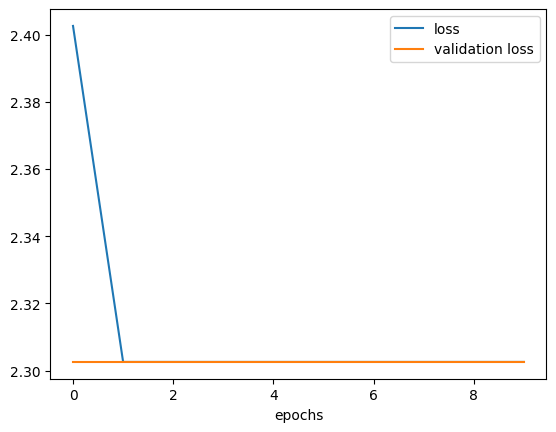

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=tf.keras.datasets.mnist
(train_images,train_labels),(test_images,test_labels)=df.load_data()
xtrain=train_images.reshape(train_images.shape[0],-1)
xtest=test_images.reshape(test_images.shape[0],-1)
normalizer=tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(xtrain)
model=tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu')
])
model.compile(loss='sparse_categorical_crossentropy',optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),metrics=['accuracy'])
history=model.fit(xtrain, train_labels,epochs=10,validation_split=0.2)
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel('epochs')
plt.legend()
test_loss,test_accuracy=model.evaluate(xtest, test_labels)
print("Loss: ",test_loss)
print("Accuracy: ",test_accuracy)
sample_image=xtest[0:1]
predictions=model.predict(tf.constant(sample_image))
predicted_class=np.argmax(predictions[0])
print("Predicted: ",predicted_class)
print(f"Actual: ",test_labels[0])